In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax.numpy as jnp
from model import FNSCircuit

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/DistributedVisualCortex/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
num_exc_neurons = (100, 100)
num_inh_neurons = 100
FNSnet = FNSCircuit(num_exc_neurons, num_inh_neurons)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/DistributedVisualCortex/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/DistributedVisualCortex/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


In [3]:
if np.product(FNSnet.E.size) <= 50:
    conn = FNSnet.E2E.proj.comm.conn
    positions = FNSnet.E.positions
    if len(positions[0]) == 1:
        positions = [(x[0], 0) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    nx.draw(
        G,
        pos=positions,
        connectionstyle="arc3,rad=0.5",
        node_color="b",
        edge_color="b",
        node_size=20,
        width=0.5,
    )

    conn = FNSnet.I2I.proj.comm.conn
    positions = FNSnet.I.positions
    if len(positions[0]) == 1:
        positions = [(x[0], 0) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    nx.draw_networkx_nodes(G, pos=positions, node_color="r", node_size=20)

    plt.show()


In [4]:
# input, T = bp.inputs.section_input([0.0, 400.0], [100.0, 100.0], return_length=True)
# inputs = np.zeros(FNSnet.E.size + (len(input),))
# inputs[0, 0] = input
# inputs = inputs.reshape(-1, inputs.shape[-1])

# inputs = np.zeros(FNSnet.E.size).flatten() + 400.0
# inputs = np.tile(
#     inputs, (int(T / bp.share.load("dt")), 1)
# ).transpose()  # A matrix doesn't work. Maybe add a new input variable post-hoc that
# targets a specific set of indices?

# input = 400.0
# input_idxs = (range(2), range(2))
# FNSnet.stimulus = bp.dyn.InputVar([len(x) for x in input_idxs])
# FNSnet.E.add_inp_fun("", self.Ein)

def stimulus():
    out = jnp.zeros(FNSnet.E.size)
    t = bp.share['t']
    out = out.at[0:4, 0:4].add(jnp.where(jnp.logical_and(t > 0., t < 5.), 400.0, 0.0))
    out = out.at[0:4, 0:4].add(jnp.where(jnp.logical_and(t > 400., t < 405.), 400.0, 0.0))
    return out.flatten()

In [5]:
T = 500.0
runner = bp.DSRunner(
    FNSnet,
    monitors=["E.spike", "I.spike"],
    inputs=[
        ("Ein.input", stimulus, 'func'),
    ],
    jit = True
)
runner.run(T)
t = runner.mon["ts"].view()  # [1000:]
X = runner.mon["E.spike"].view()  # [1000:]

Predict 5000 steps: : 100%|██████████| 5000/5000 [00:06<00:00, 751.69it/s]


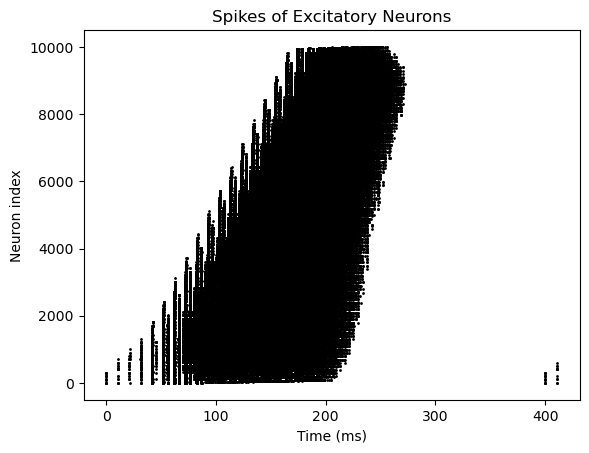

In [6]:
bp.visualize.raster_plot(t, X, title="Spikes of Excitatory Neurons", show=True)

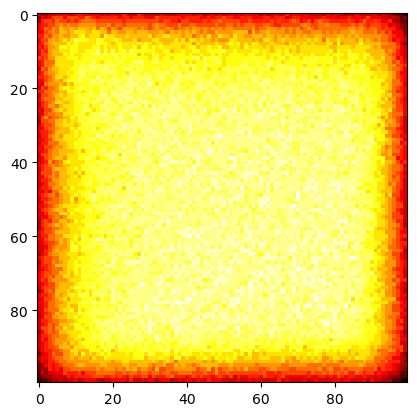

[[ 8  7  7 ...  5  5  4]
 [ 6  9  8 ...  7  5  6]
 [ 7 10 11 ...  7  5  5]
 ...
 [ 5  8  6 ...  7  5  5]
 [ 5  6  7 ...  6  5  5]
 [ 4  5  5 ...  5  4  3]]


In [7]:
R = X.sum(axis=0)
R = R.reshape(FNSnet.E.size)
plt.imshow(R, cmap="hot", interpolation="nearest")
plt.show()
print(R)